In [3]:
# 1. Carga el archivo "titanic.csv" y realiza el primer contacto con el dataset.
# Reporta dimensiones, primeras filas, tipos de datos y define con tus palabras qué representa una fila.
# Pista de trabajo: "shape", "head()", "info()" y "dtypes".

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.get_dataset_names()
df = sns.load_dataset("titanic")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [4]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [7]:
# 2. Clasifica las variables "survived", "pclass", "sex", "age", "sibsp", "fare", "embarked", "deck" y "alone" como cuantitativas o cualitativas;
# cuando corresponda, indica si son discretas/continuas o nominales/ordinales. Explica al menos dos “disfraces numéricos”.
# Pista de trabajo: No clasifiques solo por el dtype de pandas; piensa en el significado.

clasificacion_variables = pd.DataFrame({
    "variable": [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "fare",
        "embarked",
        "deck",
        "alone"
    ],
    "clasificacion" : [
        "categorica - nominal",
        "categorica - ordinal",
        "categorica - nominal",
        "numerica - discreta",
        "numerica - discreta",
        "numerica - continua",
        "categorica - nominal",
        "categorica - nominal",
        "categorica - nominal"
    ]
})

clasificacion_variables

,variable,clasificacion
0,survived,categorica - nominal
1,pclass,categorica - ordinal
2,sex,categorica - nominal
3,age,numerica - discreta
4,sibsp,numerica - discreta
5,fare,numerica - continua
6,embarked,categorica - nominal
7,deck,categorica - nominal
8,alone,categorica - nominal


In [8]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# 3. Analiza los valores faltantes.
# Calcula cantidad y porcentaje de nulos por columna, ordénalos de mayor a menor y
# propone una estrategia razonada para "deck", "age" y "embarked"/"embark_town".

valores_nulos = pd.DataFrame({
    "numero_nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("porcentaje", ascending=False)

valores_nulos

,numero_nulos,porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000


In [10]:
# 4. Busca filas exactamente duplicadas.
# ¿Cuántas hay? Explica por qué “fila duplicada” no equivale necesariamente a “pasajero duplicado”
# en este archivo y por qué no deberías eliminarlas automáticamente.

num_duplicados = df.duplicated().sum()
duplicados = df[df.duplicated(keep=False)].sort_values(list(df.columns))

print(num_duplicados)

107


In [11]:
duplicados.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
64,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
144,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
658,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
733,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
734,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
134,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
343,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
666,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True


In [12]:
# 5. Calcula estadísticos descriptivos de "age" y "fare": media, mediana, desviación estándar,
# Q1, Q3 e IQR. Compara media y mediana y comenta qué sugieren sobre la forma de cada distribución.

resumen = df[["age", "fare"]].agg(["mean", "median", "std"])
# resumen

q = df[["age", "fare"]].quantile([0.25, 0.75]).T
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]
q

,q1,q3,iqr
age,20.1250,38.0,17.8750
fare,7.9104,31.0,23.0896


In [13]:
resumen

,age,fare
mean,29.699118,32.204208
median,28.000000,14.454200
std,14.526497,49.693429


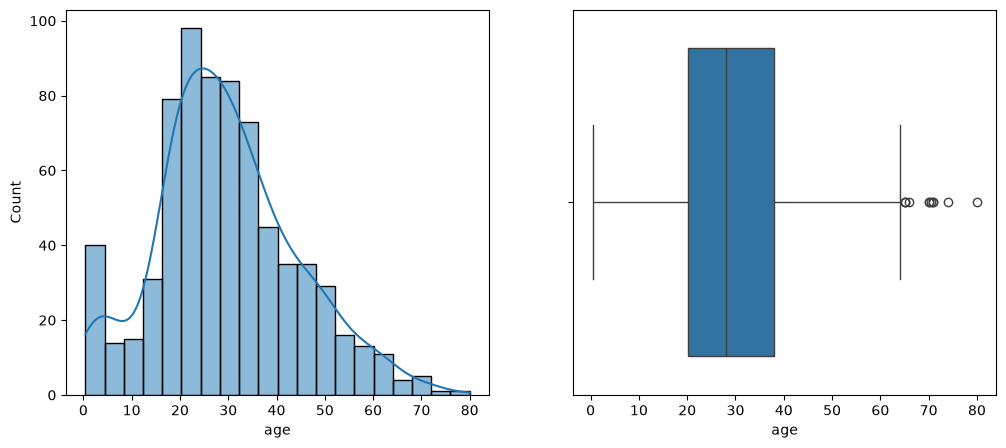

In [14]:
# 6. Realiza un análisis univariado de "age" mediante histograma y curva KDE. Describe centro, dispersión, forma y cualquier precaución por los datos faltantes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0])

sns.boxplot(data=df, x="age", ax=axes[1])

plt.show()

age     -6.6875
fare   -26.7240
dtype: float64
age     64.8125
fare    65.6344
dtype: float64


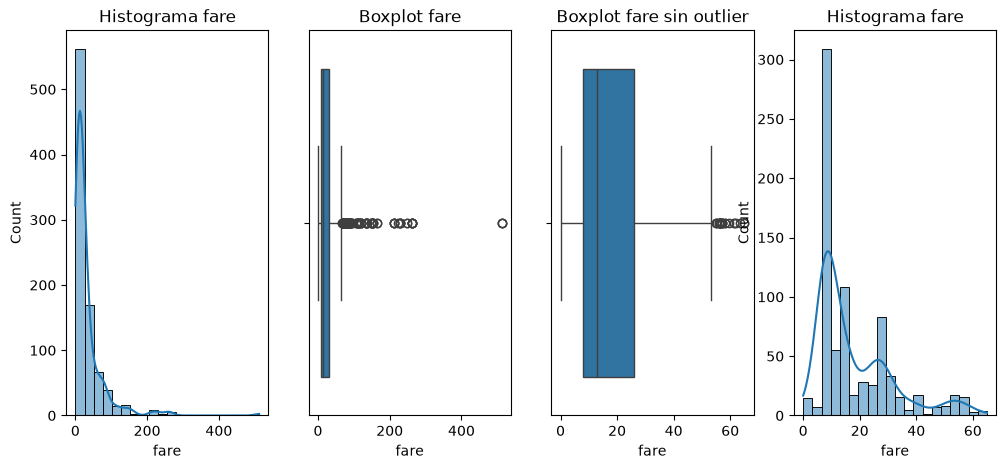

In [15]:
# 7. Analiza "fare" con histograma y boxplot.
# Calcula los límites de outliers mediante la regla 1.5·IQR y cuenta cuántas observaciones quedan fuera. ¿Los eliminarías? Justifica.
# Pista de trabajo: Un outlier no es automáticamente un error.

fig, axes = plt.subplots(1, 4, figsize=(12, 5))
sns.histplot(data=df, x="fare", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histograma fare")

sns.boxplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Boxplot fare")

q = df[["age", "fare"]].quantile([0.25, 0.75]).T

q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]

lower = q["q1"] - 1.5 * q["iqr"]
print(lower)

upper = q["q3"] + 1.5 * q["iqr"]
print(upper)

df_sin_outlier = df[(df["fare"] > lower["fare"]) & (df["fare"] < upper["fare"])]

sns.boxplot(data=df_sin_outlier, x="fare", ax=axes[2])
axes[2].set_title("Boxplot fare sin outlier")

sns.histplot(data=df_sin_outlier, x="fare", bins=20, kde=True, ax=axes[3])
axes[3].set_title("Histograma fare")

plt.show()

In [16]:
df_sin_outlier["fare"].min()

np.float64(0.0)

In [17]:
df_sin_outlier["fare"].max()

np.float64(65.0)

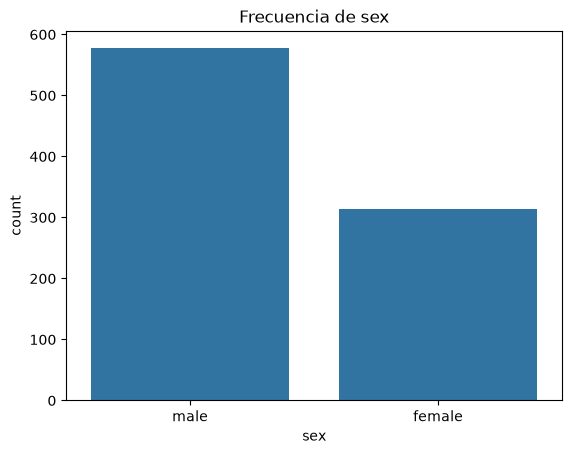

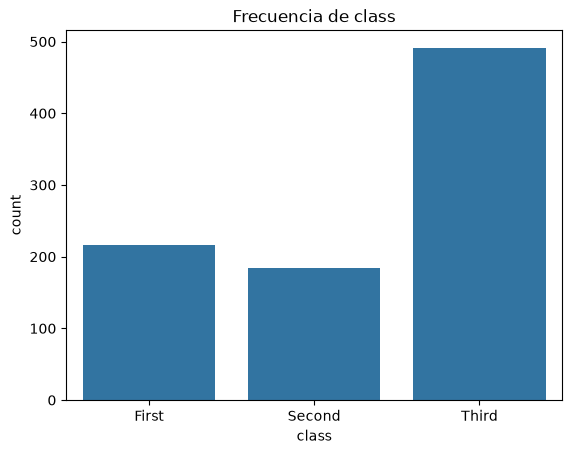

In [18]:
# 8. Explora las variables categóricas "sex" y "class" con tablas de frecuencia y gráficos de barras. ¿Qué grupos dominan el dataset y qué implicación puede tener para las comparaciones?

for col in ["sex", "class"]:
    sns.countplot(data=df, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

survived
0    549
1    342
Name: count, dtype: int64
38.38383838383838


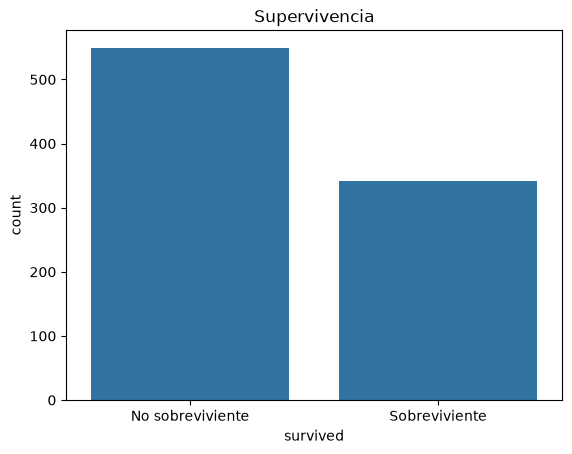

In [19]:
# 9. Calcula la tasa global de supervivencia y represéntala gráficamente. Interpreta la diferencia entre contar supervivientes y calcular una tasa.
counts = df["survived"].value_counts()
print(counts)

tasa = df["survived"].mean() * 100
print(tasa)

sns.countplot(data=df, x="survived")
plt.xticks([0, 1], ["No sobreviviente", "Sobreviviente"])
plt.title("Supervivencia")
plt.show()

        count       mean
sex                     
female    314  74.203822
male      577  18.890815


<Axes: xlabel='sex', ylabel='survived'>

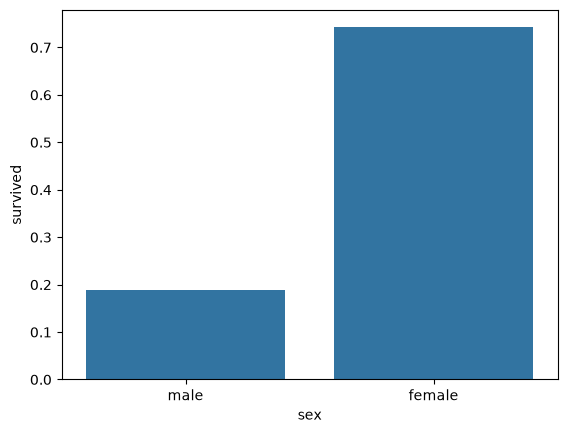

In [20]:
# 10. Compara la tasa de supervivencia entre mujeres y hombres. Incluye una tabla y un gráfico. Describe la asociación observada sin usar lenguaje causal.
# Pista de trabajo: "groupby()" o "pd.crosstab(..., normalize=...)".

sex_rate = df.groupby("sex")["survived"].agg(["count", "mean"])
sex_rate["mean"] *= 100

print(sex_rate)

sns.barplot(data=df, x="sex", y="survived", errorbar=None)

        count       mean
class                   
First     216  62.962963
Second    184  47.282609
Third     491  24.236253


<Axes: xlabel='class', ylabel='survived'>

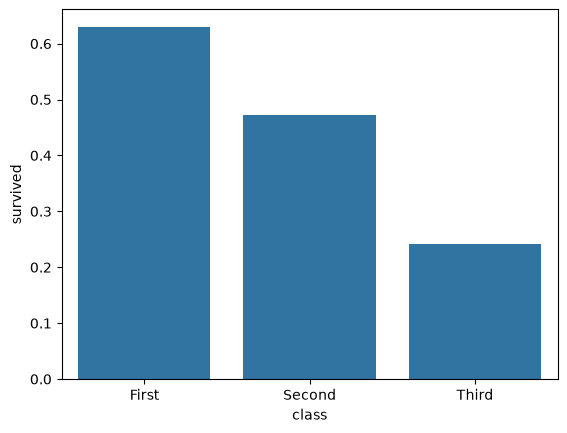

In [21]:
# 11. Compara la tasa de supervivencia entre primera, segunda y tercera clase. ¿Existe un gradiente visible entre las clases?
class_rate = df.groupby("class")["survived"].agg(["count", "mean"])
class_rate["mean"] *= 100

print(class_rate)

sns.barplot(data=df, x="class", y="survived", errorbar=None)

          count       mean  median        std
survived                                     
0           424  30.626179    28.0  14.172110
1           290  28.343690    28.0  14.950952


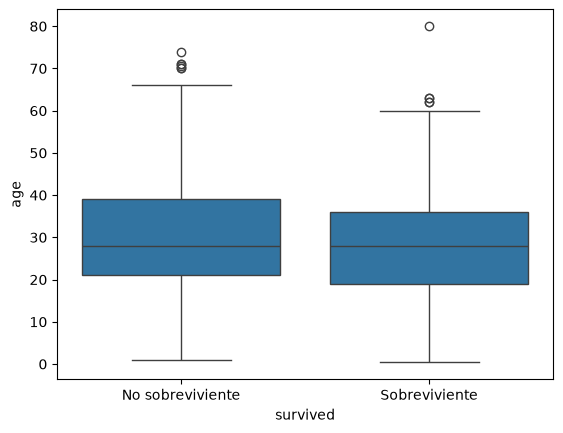

In [22]:
# 12. Compara la distribución de "age" entre quienes sobrevivieron y quienes no mediante boxplot o violín.
#  Calcula también la mediana por grupo. ¿La edad parece separar claramente a ambos grupos?

age_stats = df.groupby("survived")["age"].agg(["count", "mean", "median", "std"])
print(age_stats)

sns.boxplot(data=df, x="survived", y="age")
plt.xticks([0, 1], ["No sobreviviente", "Sobreviviente"])
plt.show()

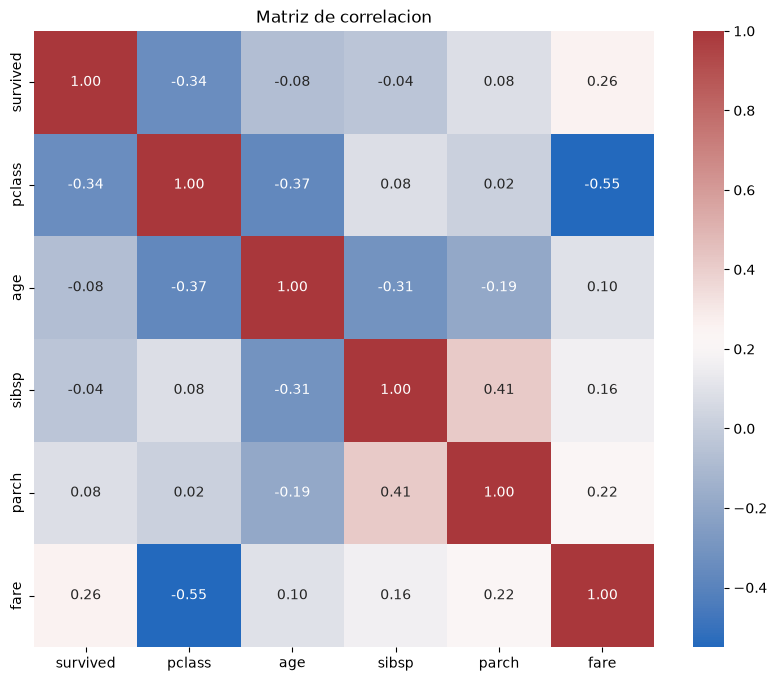

In [23]:
# 13. Construye una matriz de correlación para las variables numéricas y un heatmap.
# Identifica las relaciones lineales más relevantes con "survived" y explica por qué correlación no implica causalidad.


columns_numericas = df.select_dtypes(include="number")
corr = columns_numericas.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag")
plt.title("Matriz de correlacion")
plt.show()

In [24]:
# 14. Audita columnas potencialmente redundantes o derivadas: compara "survived" con "alive", "pclass" con "class",
# "embarked" con "embark_town", y reflexiona sobre "who", "adult_male" y "alone".
# ¿Qué riesgo habría al usar columnas que repiten o derivan información en un modelo?

pd.crosstab(df["survived"], df["alive"])

alive,no,yes
survived,,
0,549,0
1,0,342


In [25]:
pd.crosstab(df["pclass"], df["class"])

class,First,Second,Third
pclass,,,
1,216,0,0
2,0,184,0
3,0,0,491


In [26]:
pd.crosstab(df["embarked"], df["embark_town"])

embark_town,Cherbourg,Queenstown,Southampton
embarked,,,
C,168,0,0
Q,0,77,0
S,0,0,644


In [27]:
df[["sex", "age", "who", "adult_male", "alone", "sibsp", "parch"]].sort_values("age", ascending=False).head(20)

,sex,age,who,adult_male,alone,sibsp,parch
630,male,80.0,man,True,True,0,0
851,male,74.0,man,True,True,0,0
493,male,71.0,man,True,True,0,0
96,male,71.0,man,True,True,0,0
116,male,70.5,man,True,True,0,0
672,male,70.0,man,True,True,0,0
745,male,70.0,man,True,False,1,1
33,male,66.0,man,True,True,0,0
54,male,65.0,man,True,False,0,1
280,male,65.0,man,True,True,0,0


<Axes: xlabel='class', ylabel='survived'>

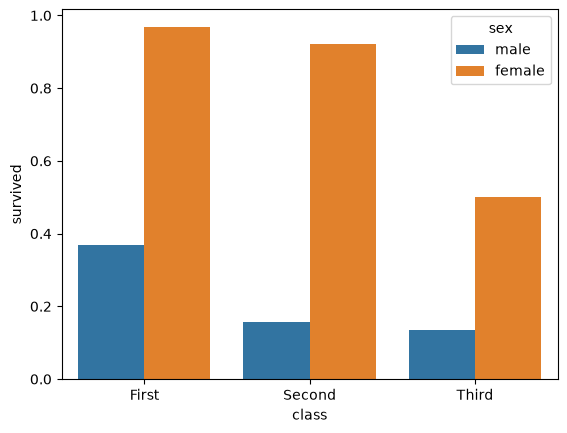

In [28]:
# 15. Realiza un análisis multivariado de supervivencia combinando al menos "sex" y "class".

sns.barplot(data=df, x="class", y="survived", hue="sex", order=["First", "Second", "Third"], errorbar=None)

In [29]:
# 16. Crea una variable "family_size = sibsp + parch + 1".
# Analiza su distribución y comprueba si es coherente con la variable "alone". ¿Encuentras contradicciones entre ambas?
df_copy = df.copy()
df_copy["family_size"] = df_copy["sibsp"] + df_copy["parch"] + 1

pd.crosstab(df_copy["family_size"], df_copy["alone"])

alone,False,True
family_size,,
1,0,537
2,161,0
3,102,0
4,29,0
5,15,0
6,22,0
7,12,0
8,6,0
11,7,0


<Axes: xlabel='family_size', ylabel='tasa'>

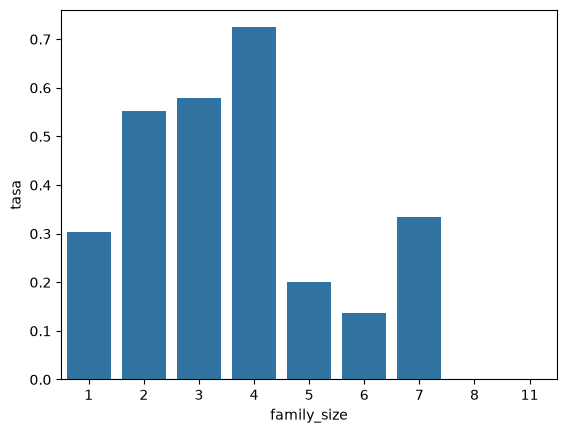

In [30]:
# 17. Compara la tasa de supervivencia según "family_size" y según "alone".
# ¿La relación parece lineal? Identifica grupos con tasas altas o bajas y revisa el tamaño de cada grupo antes de interpretar.
tasa_supervivencia = df_copy.groupby("family_size", as_index=False)["survived"].agg(n="count", tasa="mean")
tasa_supervivencia

sns.barplot(data=tasa_supervivencia, x="family_size", y="tasa")

In [38]:
# 18. Agrupa "age" en intervalos razonables (por ejemplo, niñez, adolescencia, adulto joven, adulto y adulto mayor) y compara la supervivencia entre grupos.
#  Explica qué información se gana y qué información se pierde al discretizar una variable continua.

bins = [0, 12, 18, 35, 60, float("inf")]
labels = ["Ninez (0-12)", "Adolescencia (13-18)", "Adulto Joven (19-35)", "Adulto (36-60)", "Adulto Mayor (>60)"]
df_copy = df.copy()

df_copy["age_grupo"] = pd.cut(df_copy["age"], bins=bins, labels=labels, include_lowest=True)

df_supervivencia = df_copy.groupby("age_grupo", as_index=False)["survived"].agg(n="count", tasa="mean")
df_supervivencia


,age_grupo,n,tasa
0,Ninez (0-12),69,0.579710
1,Adolescencia (13-18),70,0.428571
2,Adulto Joven (19-35),358,0.382682
3,Adulto (36-60),195,0.400000
4,Adulto Mayor (>60),22,0.227273


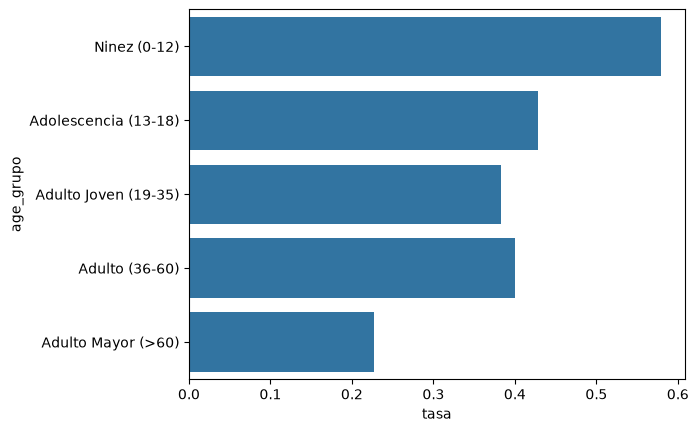

In [46]:
sns.barplot(data=df_supervivencia, x="tasa", y="age_grupo", orient="h")
plt.show()

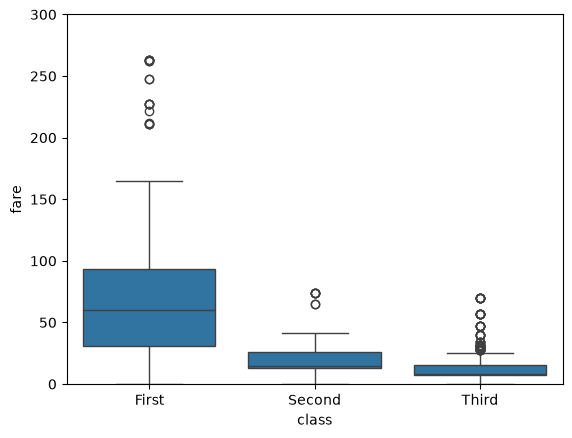

In [55]:
# 19. Compara la distribución de "fare" entre las clases del Titanic con boxplots y estadísticas por grupo.
# ¿Qué relación existe entre tarifa y clase, y por qué esto obliga a ser cuidadoso al interpretar la asociación entre "fare" y "survived"?

fare_class = df.groupby("class")["fare"].agg(n="count", media="mean", mediana="median")
# fare_class

sns.boxplot(data=df, x="class", y="fare")
plt.ylim(0, 300)
plt.show()

In [53]:
fare_class

,n,media,mediana
class,,,
First,216,84.154687,60.2875
Second,184,20.662183,14.2500
Third,491,13.675550,8.0500


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [58]:
# 20. Explora "embark_town" de forma bivariada: calcula la supervivencia por puerto y examina cómo se distribuyen las clases dentro de cada puerto.
#  ¿Las diferencias de supervivencia por puerto podrían estar mezcladas con la composición por clase?
supervivencia_puerto = df.groupby("embark_town")["survived"].agg(n="count", tasa="mean")
supervivencia_puerto

,n,tasa
embark_town,,
Cherbourg,168,0.553571
Queenstown,77,0.389610
Southampton,644,0.336957


In [59]:
pd.crosstab(df["embark_town"], df["class"], normalize="index")

class,First,Second,Third
embark_town,,,
Cherbourg,0.505952,0.101190,0.392857
Queenstown,0.025974,0.038961,0.935065
Southampton,0.197205,0.254658,0.548137


In [61]:
# 21. Investiga si los valores faltantes parecen distribuirse al azar.
# Crea indicadores de ausencia para "age" y "deck" y compara sus porcentajes por "class" y por "survived". ¿Qué patrón observas?
df_copy["age_nulos"] = df_copy["age"].isna()
df_copy["deck_nulos"] = df_copy["deck"].isna()

df_copy.groupby("class")[["age_nulos", "deck_nulos"]].mean()

,age_nulos,deck_nulos
class,,
First,0.138889,0.189815
Second,0.059783,0.913043
Third,0.276986,0.975560


In [62]:
df_copy.groupby("survived")[["age_nulos", "deck_nulos"]].mean()

,age_nulos,deck_nulos
survived,,
0,0.227687,0.877960
1,0.152047,0.602339


In [65]:
# 22. Compara dos reglas para detectar valores extremos en "fare": 1.5·IQR y |z| > 3.
# ¿Cuántos casos identifica cada método? ¿Coinciden completamente? Explica por qué dos métodos pueden producir resultados distintos.

# UTILIZANDO IQR PARA VALORES ATIPICOS U OUTLIERS CUANDO LAS DISTRIBUCIONES SON ASIMETRICAS
fare = df["fare"].dropna()
q1, q3 = fare.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outs = (df["fare"] < lower) | (df["fare"] > upper)
print("Total de outliers con iqr:" , iqr_outs.sum())

# UTILIZANDO Z-SCORE: UTILIZARLO CUANDO LAS DISTRIBUCIONES SON SIMETRICAS
z = (fare - fare.mean()) / fare.std()
z_outs = z.abs() > 3
print("Total de outliers con z_score:", z_outs.sum())

Total de outliers con iqr: 116
Total de outliers con z_score: 20


In [67]:
# 23. Construye una tabla de contingencia normalizada entre "sex" y "class". ¿La composición por clase es igual para mujeres y hombres?
#  Explica por qué esta diferencia es relevante antes de comparar tasas de supervivencia por sexo.
sex_class = pd.crosstab(df["sex"], df["class"], normalize="index")
sex_class

class,First,Second,Third
sex,,,
female,0.299363,0.242038,0.458599
male,0.211438,0.187175,0.601386


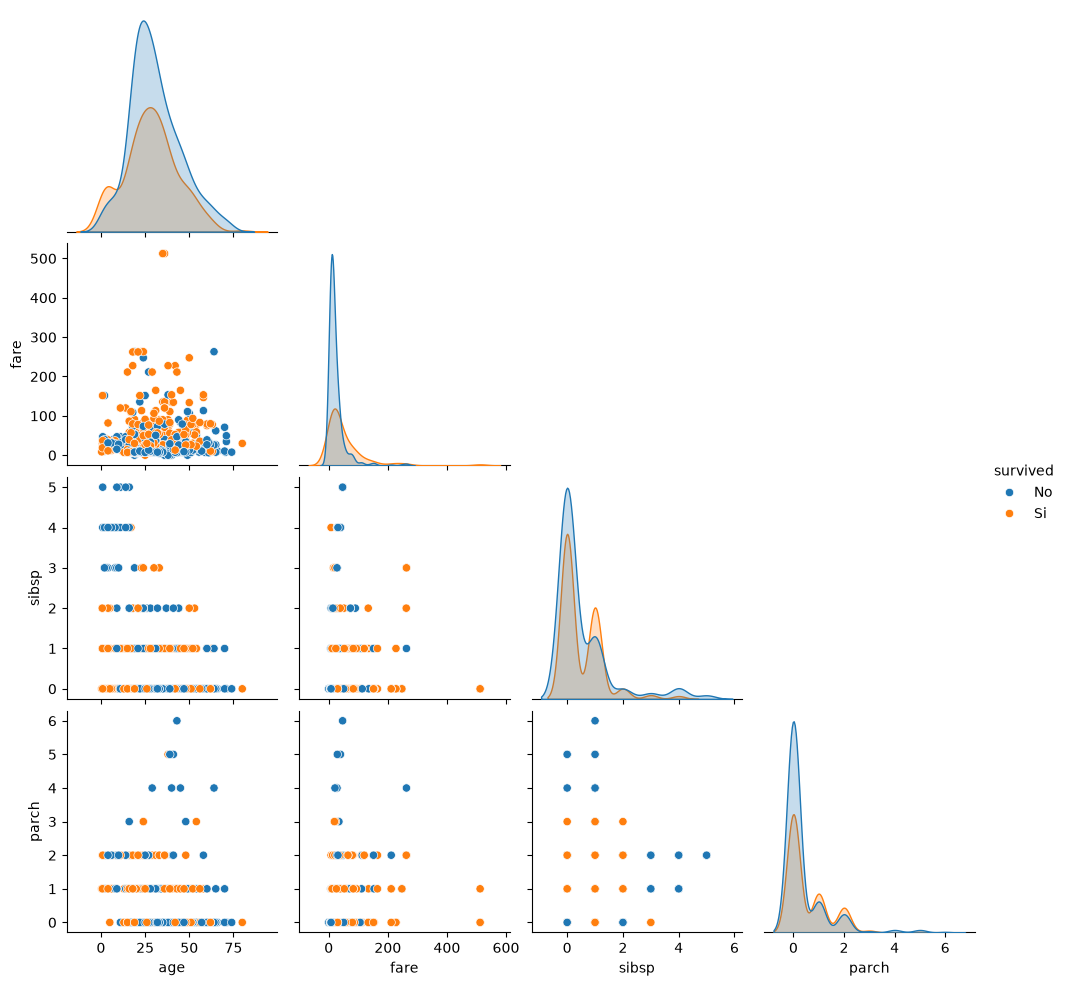

In [70]:
# 24. Construye un "pairplot" o una matriz de dispersión con "age", "fare", "sibsp", "parch" y "survived".
#  Describe al menos tres patrones, superposiciones o relaciones que no serían evidentes mirando solo una correlación.
pair_plot = df[["age", "fare", "sibsp", "parch", "survived"]].dropna()
pair_plot["survived"] = pair_plot["survived"].map({0: "No", 1: "Si"})
sns.pairplot(pair_plot, vars=["age", "fare", "sibsp", "parch"], hue="survived", corner=True)
plt.show()

In [71]:
# 25. Elabora un “registro de decisiones” del EDA: para "age", "deck", "embarked", "alive", "class" y
# los duplicados aparentes, indica si conservarías, transformarías, imputarías, eliminarías o investigarías más antes de modelar.
#  Justifica cada decisión y cierra con tres hallazgos, dos hipótesis y dos limitaciones.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
